In [46]:
import pandas as pd
import numpy as np

# тут я у ГПТ уточнил как нам перекинуть сырье в другую папку, чтобы не было проблем с путями
race_results = pd.read_csv("../data/raw/race_results.csv")
quali_results = pd.read_csv("../data/raw/quali_results.csv")
drivers = pd.read_csv("../data/raw/drivers.csv")
weather = pd.read_csv("../data/raw/weather.csv")
meetings = pd.read_csv("../data/raw/meetings.csv")
laps_agg = pd.read_csv("../data/raw/laps_agg.csv")
sessions = pd.read_csv("../data/raw/sessions.csv")

print("результаты гонок:", race_results.shape)
print("результаты квал:", quali_results.shape)
print("пилоты:", drivers.shape)
print("погода:", weather.shape)
print("трассы:", meetings.shape)
print("телеметрия:", laps_agg.shape)
print("сессии:", sessions.shape)

результаты гонок: (1397, 11)
результаты квал: (1377, 10)
пилоты: (1397, 5)
погода: (70, 6)
трассы: (74, 7)
телеметрия: (1394, 9)
сессии: (364, 15)


In [47]:
# колонки трассы, которые берем (используем и для гонки, и для квалы)
track_cols = ["meeting_key", "country_name", "circuit_short_name", "circuit_type", "year"]

In [48]:
race = race_results.copy()

#пилоты и команды (по сессии + номеру)
race = race.merge(drivers, on=["session_key", "driver_number"], how="left")

#телеметрия (по сессии + номеру)
race = race.merge(laps_agg, on=["session_key", "driver_number"], how="left")

# погода (по сессии)
race = race.merge(weather, on="session_key", how="left")


#трасса (по уикенду)
race = race.merge(meetings[track_cols], on="meeting_key", how="left")

print("гонка:", race.shape)

гонка: (1397, 30)


In [49]:
# команды привязываем к уикенду (meeting_key), а не к сессии квалы
driver_team = race_results[["meeting_key", "driver_number"]].merge(drivers[["driver_number", "team_name", "full_name", "name_acronym"]],on="driver_number", how="left")
driver_team = driver_team.drop_duplicates(subset=["meeting_key", "driver_number"])

# погоду тоже привязываем к уикенду
weather_meeting = race_results[["session_key", "meeting_key"]].drop_duplicates().merge(weather, on="session_key", how="left")

weather_cols = ["meeting_key", "air_temp_mean", "track_temp_mean", "humidity_mean", "wind_speed_mean", "rainfall_max"]
weather_meeting = weather_meeting[weather_cols].drop_duplicates(subset=["meeting_key"])

# собираем квалу
quali = quali_results.copy()
quali = quali.merge(driver_team, on=["meeting_key", "driver_number"], how="left")
quali = quali.merge(weather_meeting, on="meeting_key", how="left")
quali = quali.merge(meetings[track_cols], on="meeting_key", how="left")

print("квала:", quali.shape)
print("команды заполнены:", quali["team_name"].notna().sum(), "из", len(quali))

квала: (1377, 22)
команды заполнены: 1375 из 1377


In [50]:
session_dates = sessions[["session_key", "date_start"]].copy()
session_dates["date_start"] = pd.to_datetime(session_dates["date_start"])

race = race.merge(session_dates, on="session_key", how="left")
race = race.sort_values("date_start").reset_index(drop=True)

quali = quali.merge(session_dates, on="session_key", how="left")
quali = quali.sort_values("date_start").reset_index(drop=True)

print("гонка:", race.shape, " даты:", race["date_start"].min(), "—", race["date_start"].max())
print("квала:", quali.shape, " даты:", quali["date_start"].min(), "—", quali["date_start"].max())

гонка: (1397, 31)  даты: 2023-03-05 15:00:00+00:00 — 2025-12-07 13:00:00+00:00
квала: (1377, 23)  даты: 2023-03-04 15:00:00+00:00 — 2025-12-06 14:00:00+00:00


In [51]:
import os
os.makedirs("../data/raw", exist_ok=True)

race.to_csv("../data/raw/dataset_race_raw.csv", index=False)
quali.to_csv("../data/raw/dataset_quali_raw.csv", index=False)

print("сохранено:")
print("гонка:", race.shape)
print("квала:", quali.shape)

сохранено:
гонка: (1397, 31)
квала: (1377, 23)


In [52]:
import pandas as pd
import numpy as np

# данные лежат в соседней папке data/raw/, поэтому ../data/
race_results = pd.read_csv("../data/raw/race_results.csv")
quali_results = pd.read_csv("../data/raw/quali_results.csv")
drivers = pd.read_csv("../data/raw/drivers.csv")
weather = pd.read_csv("../data/raw/weather.csv")
meetings = pd.read_csv("../data/raw/meetings.csv")
laps_agg = pd.read_csv("../data/raw/laps_agg.csv")
sessions = pd.read_csv("../data/raw/sessions.csv")

print("результаты гонок:", race_results.shape)
print("результаты квал:", quali_results.shape)
print("пилоты:", drivers.shape)
print("погода:", weather.shape)
print("трассы:", meetings.shape)
print("телеметрия:", laps_agg.shape)
print("сессии:", sessions.shape)

результаты гонок: (1397, 11)
результаты квал: (1377, 10)
пилоты: (1397, 5)
погода: (70, 6)
трассы: (74, 7)
телеметрия: (1394, 9)
сессии: (364, 15)


этап 2 - feature engineering

driver_form_5 — средняя позиция пилота за последние 5 прошлых гонок (недавняя форма)
driver_form_all — средняя позиция за все прошлые гонки (общий уровень) ← с этой начали
team_form_5 — средняя позиция команды за последние 5 гонок (сила болида)
driver_track_history — средняя позиция пилота на этой трассе раньше
driver_finish_rate — доля прошлых гонок без схода (надёжность)
driver_experience — сколько гонок проехал до текущей (опыт)
driver_speed_5 — средняя макс-скорость за прошлые 5 гонок (телеметрия)

In [ ]:
# сортируем по пилоту и дате: у каждого пилота гонки по порядку времени
race = race.sort_values(["driver_number", "date_start"]).reset_index(drop=True)

#1 сдвигаем позицию на гонку назад внутри пилота (прячем текущую гонку)
race["pos_shifted"] = race.groupby("driver_number")["position"].shift(1)

#2  средняя позиция за ВСЕ прошлые гонки (накопительное среднее)
race["driver_form_all"] = (race.groupby("driver_number")["pos_shifted"].expanding().mean().values)

#3 средняя позиция за последние 5 прошлых гонок (недавняя форма)
race["driver_form_5"] = (race.groupby("driver_number")["pos_shifted"].rolling(5).mean().values)

# убираем временную колонку
race = race.drop(columns=["pos_shifted"])

# возвращаем сортировку по дате
race = race.sort_values("date_start").reset_index(drop=True)

race[["date_start", "name_acronym", "position", "driver_form_all", "driver_form_5"]].head(15)

,date_start,name_acronym,position,driver_form_all,driver_form_5
0,2023-03-05 15:00:00+00:00,VER,1.0,NaN,NaN
1,2023-03-05 15:00:00+00:00,SAR,12.0,NaN,NaN
2,2023-03-05 15:00:00+00:00,ALB,10.0,NaN,NaN
3,2023-03-05 15:00:00+00:00,OCO,NaN,NaN,NaN
4,2023-03-05 15:00:00+00:00,TSU,11.0,NaN,NaN
5,2023-03-05 15:00:00+00:00,NOR,17.0,NaN,NaN
6,2023-03-05 15:00:00+00:00,DEV,14.0,NaN,NaN
7,2023-03-05 15:00:00+00:00,MAG,13.0,NaN,NaN
8,2023-03-05 15:00:00+00:00,HUL,15.0,NaN,NaN
9,2023-03-05 15:00:00+00:00,BOT,8.0,NaN,NaN


In [ ]:
# пример чисто 
ver = race[race["name_acronym"] == "VER"]
ver[["date_start", "position", "driver_form_all", "driver_form_5"]].head(10)

                   date_start  position  driver_form_all  driver_form_5
0   2023-03-05 15:00:00+00:00       1.0              NaN            NaN
39  2023-03-19 17:00:00+00:00       2.0         1.000000            NaN
48  2023-04-02 05:00:00+00:00       1.0         1.500000            NaN
75  2023-04-30 11:00:00+00:00       2.0         1.333333            NaN
89  2023-05-07 19:30:00+00:00       1.0         1.500000            NaN
114 2023-05-28 13:00:00+00:00       1.0         1.400000            1.4
126 2023-06-04 13:00:00+00:00       1.0         1.333333            1.4
152 2023-06-18 18:00:00+00:00       1.0         1.285714            1.2
169 2023-07-02 13:00:00+00:00       1.0         1.250000            1.2
194 2023-07-09 14:00:00+00:00       1.0         1.222222            1.0


In [55]:
# сортируем по команде и дате
race = race.sort_values(["team_name", "date_start"]).reset_index(drop=True)

# сдвигаем позицию на гонку назад внутри команды (прячем текущую гонку)
race["pos_shifted"] = race.groupby("team_name")["position"].shift(1)

# средняя позиция команды за последние 5 прошлых гонок (сила болида)
race["team_form_5"] = race.groupby("team_name")["pos_shifted"].rolling(5).mean().values

# убираем временную колонку
race = race.drop(columns=["pos_shifted"])

# возвращаем сортировку по дате
race = race.sort_values("date_start").reset_index(drop=True)

race[["date_start", "team_name", "name_acronym", "position", "team_form_5"]].head(15)

,date_start,team_name,name_acronym,position,team_form_5
0,2023-03-05 15:00:00+00:00,Alfa Romeo,BOT,8.0,NaN
1,2023-03-05 15:00:00+00:00,Ferrari,SAI,4.0,NaN
2,2023-03-05 15:00:00+00:00,Haas F1 Team,MAG,13.0,NaN
3,2023-03-05 15:00:00+00:00,Haas F1 Team,HUL,15.0,NaN
4,2023-03-05 15:00:00+00:00,AlphaTauri,TSU,11.0,NaN
5,2023-03-05 15:00:00+00:00,AlphaTauri,DEV,14.0,NaN
6,2023-03-05 15:00:00+00:00,McLaren,PIA,NaN,NaN
7,2023-03-05 15:00:00+00:00,Williams,SAR,12.0,NaN
8,2023-03-05 15:00:00+00:00,McLaren,NOR,17.0,NaN
9,2023-03-05 15:00:00+00:00,Aston Martin,ALO,3.0,NaN


In [ ]:
# сортируем по пилоту, трассе и дате
race = race.sort_values(["driver_number", "circuit_short_name", "date_start"]).reset_index(drop=True)

# сдвигаем позицию назад внутри пары пилот+трасса (прячем текущую гонку)
race["pos_shifted"] = race.groupby(["driver_number", "circuit_short_name"])["position"].shift(1)

# средняя позиция пилота на ЭТОЙ трассе в прошлом
race["driver_track_history"] = (race.groupby(["driver_number", "circuit_short_name"])["pos_shifted"].expanding().mean().values)

# убираем временную колонку
race = race.drop(columns=["pos_shifted"])

# возвращаем сортировку по дате
race = race.sort_values("date_start").reset_index(drop=True)

race[["date_start", "name_acronym", "circuit_short_name", "position", "driver_track_history"]].head(15)

,date_start,name_acronym,circuit_short_name,position,driver_track_history
0,2023-03-05 15:00:00+00:00,HAM,Sakhir,5.0,NaN
1,2023-03-05 15:00:00+00:00,ZHO,Sakhir,16.0,NaN
2,2023-03-05 15:00:00+00:00,DEV,Sakhir,14.0,NaN
3,2023-03-05 15:00:00+00:00,PER,Sakhir,2.0,NaN
4,2023-03-05 15:00:00+00:00,NOR,Sakhir,17.0,NaN
5,2023-03-05 15:00:00+00:00,STR,Sakhir,6.0,NaN
6,2023-03-05 15:00:00+00:00,VER,Sakhir,1.0,NaN
7,2023-03-05 15:00:00+00:00,HUL,Sakhir,15.0,NaN
8,2023-03-05 15:00:00+00:00,ALO,Sakhir,3.0,NaN
9,2023-03-05 15:00:00+00:00,SAI,Sakhir,4.0,NaN


In [ ]:
# отметим, финишировал ли пилот (не сошел)
# dnf = True значит сход, поэтому finished = противоположное
race["finished"] = (race["dnf"] == False).astype(int)

# сортируем по пилоту и дате
race = race.sort_values(["driver_number", "date_start"]).reset_index(drop=True)

# сдвигаем флаг финиша назад (прячем текущую гонку)
race["fin_shifted"] = race.groupby("driver_number")["finished"].shift(1)

# доля прошлых гонок, которые пилот завершил без схода
race["driver_finish_rate"] = (race.groupby("driver_number")["fin_shifted"].expanding().mean().values)

# убираем временные колонки
race = race.drop(columns=["fin_shifted"])

# возвращаем сортировку по дате
race = race.sort_values("date_start").reset_index(drop=True)

print(race[["date_start", "name_acronym", "dnf", "finished", "driver_finish_rate"]].head(15))

                  date_start name_acronym    dnf  finished  driver_finish_rate
0  2023-03-05 15:00:00+00:00          VER  False         1                 NaN
1  2023-03-05 15:00:00+00:00          SAR  False         1                 NaN
2  2023-03-05 15:00:00+00:00          ALB  False         1                 NaN
3  2023-03-05 15:00:00+00:00          OCO   True         0                 NaN
4  2023-03-05 15:00:00+00:00          TSU  False         1                 NaN
5  2023-03-05 15:00:00+00:00          NOR  False         1                 NaN
6  2023-03-05 15:00:00+00:00          DEV  False         1                 NaN
7  2023-03-05 15:00:00+00:00          MAG  False         1                 NaN
8  2023-03-05 15:00:00+00:00          HUL  False         1                 NaN
9  2023-03-05 15:00:00+00:00          BOT  False         1                 NaN
10 2023-03-05 15:00:00+00:00          HAM  False         1                 NaN
11 2023-03-05 15:00:00+00:00          GAS  False    

In [ ]:
# сортируем по пилоту и дате
race = race.sort_values(["driver_number", "date_start"]).reset_index(drop=True)

# сколько гонок пилот проехал ДО текущей
# cumcount считает с нуля и не включает текущую строку -как раз прошлые гонки
race["driver_experience"] = race.groupby("driver_number").cumcount()

race = race.sort_values("date_start").reset_index(drop=True)

race[["date_start", "name_acronym", "driver_experience"]].head(15)

,date_start,name_acronym,driver_experience
0,2023-03-05 15:00:00+00:00,VER,0
1,2023-03-05 15:00:00+00:00,SAR,0
2,2023-03-05 15:00:00+00:00,ALB,0
3,2023-03-05 15:00:00+00:00,OCO,0
4,2023-03-05 15:00:00+00:00,TSU,0
5,2023-03-05 15:00:00+00:00,NOR,0
6,2023-03-05 15:00:00+00:00,DEV,0
7,2023-03-05 15:00:00+00:00,MAG,0
8,2023-03-05 15:00:00+00:00,HUL,0
9,2023-03-05 15:00:00+00:00,BOT,0


In [ ]:
# сортируем по пилоту и дате
race = race.sort_values(["driver_number", "date_start"]).reset_index(drop=True)

# сдвигаем макс скорость назад (прячем текущую гонку)
race["speed_shifted"] = race.groupby("driver_number")["max_st_speed"].shift(1)

# средняя макс скорость пилота за последние 5 прошлых гонок
race["driver_speed_5"] = (race.groupby("driver_number")["speed_shifted"].rolling(5).mean().values)


race = race.drop(columns=["speed_shifted"])


race = race.sort_values("date_start").reset_index(drop=True)

print(race[["date_start", "name_acronym", "max_st_speed", "driver_speed_5"]].head(15))

                  date_start name_acronym  max_st_speed  driver_speed_5
0  2023-03-05 15:00:00+00:00          VER         303.0             NaN
1  2023-03-05 15:00:00+00:00          SAR         328.0             NaN
2  2023-03-05 15:00:00+00:00          ALB         324.0             NaN
3  2023-03-05 15:00:00+00:00          OCO         329.0             NaN
4  2023-03-05 15:00:00+00:00          TSU         323.0             NaN
5  2023-03-05 15:00:00+00:00          NOR         325.0             NaN
6  2023-03-05 15:00:00+00:00          DEV         320.0             NaN
7  2023-03-05 15:00:00+00:00          MAG         315.0             NaN
8  2023-03-05 15:00:00+00:00          HUL         328.0             NaN
9  2023-03-05 15:00:00+00:00          BOT         320.0             NaN
10 2023-03-05 15:00:00+00:00          HAM         333.0             NaN
11 2023-03-05 15:00:00+00:00          GAS         327.0             NaN
12 2023-03-05 15:00:00+00:00          LEC         324.0         

In [ ]:
# список наших новых фич
feature_cols = [
    "driver_form_all",
    "driver_form_5",
    "team_form_5",
    "driver_track_history",
    "driver_finish_rate",
    "driver_experience",
    "driver_speed_5",
]


print("пропуски (NaN) по фичам:")
print(race[feature_cols].isna().sum())
print()
print("всего строк:", len(race))

пропуски (NaN) по фичам:
driver_form_all          38
driver_form_5           690
team_form_5             615
driver_track_history    702
driver_finish_rate       32
driver_experience         0
driver_speed_5          252
dtype: int64

всего строк: 1397


In [ ]:
# создаем позицию для расчета формы, где сходы = последнее место
# для каждой гонки берем максимальную позицию финишировавших и сходам даем хуже

# сколько пилотов в каждой гонке (по session_key)
race["field_size"] = race.groupby("session_key")["driver_number"].transform("count")

# position_filled: если позиция есть, берем ее; если сход (NaN), ставим последнее место (field_size)
race["position_filled"] = race["position"].fillna(race["field_size"])


print(race[["name_acronym", "position", "dnf", "field_size", "position_filled"]].head(15))

   name_acronym  position    dnf  field_size  position_filled
0           VER       1.0  False          20              1.0
1           SAR      12.0  False          20             12.0
2           ALB      10.0  False          20             10.0
3           OCO       NaN   True          20             20.0
4           TSU      11.0  False          20             11.0
5           NOR      17.0  False          20             17.0
6           DEV      14.0  False          20             14.0
7           MAG      13.0  False          20             13.0
8           HUL      15.0  False          20             15.0
9           BOT       8.0  False          20              8.0
10          HAM       5.0  False          20              5.0
11          GAS       9.0  False          20              9.0
12          LEC       NaN   True          20             20.0
13          RUS       7.0  False          20              7.0
14          PER       2.0  False          20              2.0


In [ ]:
# пересчитываем форму пилота, используя position_filled (сходы учтены как последнее место)
race = race.sort_values(["driver_number", "date_start"]).reset_index(drop=True)
race["pos_shifted"] = race.groupby("driver_number")["position_filled"].shift(1)

# форма за все прошлые гонки
race["driver_form_all"] = race.groupby("driver_number")["pos_shifted"].expanding().mean().values

# форма за последние 5 гонок (min_periods=1: считаем даже если гонок меньше 5)
race["driver_form_5"] = (race.groupby("driver_number")["pos_shifted"].rolling(5, min_periods=1).mean().values)
race = race.drop(columns=["pos_shifted"])

# форма команды за последние 5 гонок
race = race.sort_values(["team_name", "date_start"]).reset_index(drop=True)
race["pos_shifted"] = race.groupby("team_name")["position_filled"].shift(1)
race["team_form_5"] = (race.groupby("team_name")["pos_shifted"].rolling(5, min_periods=1).mean().values)
race = race.drop(columns=["pos_shifted"])

# история на трассе
race = race.sort_values(["driver_number", "circuit_short_name", "date_start"]).reset_index(drop=True)
race["pos_shifted"] = race.groupby(["driver_number", "circuit_short_name"])["position_filled"].shift(1)
race["driver_track_history"] = (race.groupby(["driver_number", "circuit_short_name"])["pos_shifted"].expanding().mean().values)
race = race.drop(columns=["pos_shifted"])


race = race.sort_values("date_start").reset_index(drop=True)


print("пропуски после пересчета:")
race[feature_cols].isna().sum()

пропуски после пересчета:


driver_form_all          32
driver_form_5            32
team_form_5              13
driver_track_history    642
driver_finish_rate       32
driver_experience         0
driver_speed_5          252
dtype: int64

In [ ]:
# флаг дебютанта: мало опыта (меньше 5 гонок в датасете)
race["is_rookie"] = (race["driver_experience"] < 5).astype(int)

#  заполняем медианой (середина пелотона)
position_features = ["driver_form_all", "driver_form_5", "team_form_5", "driver_track_history"]
for col in position_features:
    race[col] = race[col].fillna(race[col].median())

# надежность заполняем медианой
race["driver_finish_rate"] = race["driver_finish_rate"].fillna(race["driver_finish_rate"].median())

# скорость заполняем медианой
race["driver_speed_5"] = race["driver_speed_5"].fillna(race["driver_speed_5"].median())

# проверяем, что пропусков не осталось
print("пропуски после заполнения:")
print(race[feature_cols].isna().sum())
print()
print("дебютантов (is_rookie=1):", race["is_rookie"].sum(), "из", len(race))

пропуски после заполнения:
driver_form_all         0
driver_form_5           0
team_form_5             0
driver_track_history    0
driver_finish_rate      0
driver_experience       0
driver_speed_5          0
dtype: int64

дебютантов (is_rookie=1): 149 из 1397


In [ ]:
# одна и та же команда под разными именами в разные годы -> приводим к единому виду
team_mapping = {
    "AlphaTauri": "Racing Bulls",
    "RB": "Racing Bulls", 
    "Alfa Romeo": "Kick Sauber",}   



race["team_name"] = race["team_name"].replace(team_mapping)


print("команды после объединения:")
race["team_name"].value_counts()

команды после объединения:


team_name
Mercedes           140
Kick Sauber        140
Racing Bulls       140
Red Bull Racing    140
McLaren            140
Haas F1 Team       140
Ferrari            140
Alpine             140
Williams           139
Aston Martin       138
Name: count, dtype: int64

In [ ]:
# пересчитываем форму команды
race = race.sort_values(["team_name", "date_start"]).reset_index(drop=True)
race["pos_shifted"] = race.groupby("team_name")["position_filled"].shift(1)

race["team_form_5"] = (race.groupby("team_name")["pos_shifted"].rolling(5, min_periods=1).mean().values)
race = race.drop(columns=["pos_shifted"])


race["team_form_5"] = race["team_form_5"].fillna(race["team_form_5"].median())


race = race.sort_values("date_start").reset_index(drop=True)

print("пропуски team_form_5:", race["team_form_5"].isna().sum())
race[["date_start", "team_name", "name_acronym", "position", "team_form_5"]]

пропуски team_form_5: 0


,date_start,team_name,name_acronym,position,team_form_5
0,2023-03-05 15:00:00+00:00,Alpine,GAS,9.0,11.2
1,2023-03-05 15:00:00+00:00,Ferrari,SAI,4.0,11.2
2,2023-03-05 15:00:00+00:00,Ferrari,LEC,NaN,4.0
3,2023-03-05 15:00:00+00:00,Haas F1 Team,HUL,15.0,11.2
4,2023-03-05 15:00:00+00:00,Haas F1 Team,MAG,13.0,15.0
...,...,...,...,...,...
1392,2025-12-07 13:00:00+00:00,Alpine,GAS,19.0,15.6
1393,2025-12-07 13:00:00+00:00,Ferrari,LEC,4.0,8.0
1394,2025-12-07 13:00:00+00:00,Ferrari,HAM,8.0,10.4
1395,2025-12-07 13:00:00+00:00,Aston Martin,STR,10.0,14.2


In [ ]:
# берем позицию из квалы (где пилот квалифицировался)
# тоже попросил помощь гпт потому что я недодумался как нам обьеденить по двум ключам meeting_key + driver_number 
quali_pos = quali_results[["meeting_key", "driver_number", "position"]].copy()
quali_pos = quali_pos.rename(columns={"position": "quali_position"})

# приклеиваем к гонке по уикенду и пилоту
race = race.merge(quali_pos, on=["meeting_key", "driver_number"], how="left")

print("пропусков в quali_position:", race["quali_position"].isna().sum())
race[["date_start", "name_acronym", "quali_position", "position"]].head(15)

пропусков в quali_position: 42


,date_start,name_acronym,quali_position,position
0,2023-03-05 15:00:00+00:00,GAS,20.0,9.0
1,2023-03-05 15:00:00+00:00,SAI,4.0,4.0
2,2023-03-05 15:00:00+00:00,LEC,3.0,NaN
3,2023-03-05 15:00:00+00:00,HUL,10.0,15.0
4,2023-03-05 15:00:00+00:00,MAG,17.0,13.0
5,2023-03-05 15:00:00+00:00,ZHO,13.0,16.0
6,2023-03-05 15:00:00+00:00,BOT,12.0,8.0
7,2023-03-05 15:00:00+00:00,PIA,18.0,NaN
8,2023-03-05 15:00:00+00:00,HAM,7.0,5.0
9,2023-03-05 15:00:00+00:00,RUS,6.0,7.0


In [67]:
# пропуски в quali_position заполняем последним местом
# логика: если квалы нет, считаем что стартовал сзади (консервативно)
race["quali_position"] = race["quali_position"].fillna(race["quali_position"].max())

print("пропусков в quali_position:", race["quali_position"].isna().sum())
print("диапазон:", race["quali_position"].min(), "-", race["quali_position"].max())

пропусков в quali_position: 0
диапазон: 1.0 - 20.0


In [ ]:
import os #попросил помощь гпт с сохранением, чтобы не было проблем с путями
os.makedirs("../data/data_final", exist_ok=True)

race.to_csv("../data/data_final/race_features.csv", index=False)

print("сохранено:", race.shape)

сохранено: (1397, 43)


Этап 3 - EDA

In [69]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [84]:
race = pd.read_csv("../data/data_final/race_features.csv")

# выкидываем дубли quali_position_x / quali_position_y 
dup_cols = [c for c in ["quali_position_x", "quali_position_y"] if c in race.columns]
race = race.drop(columns=dup_cols)

# дата в datetime - пригодится для хронологического разбиения
race["date_start"] = pd.to_datetime(race["date_start"])
race = race.sort_values("date_start").reset_index(drop=True)

print("Размер таблицы:", race.shape)
print("Гонок:", race["session_key"].nunique(),
      " пилотов:", race["driver_number"].nunique(),
      "команд:", race["team_name"].nunique(),
      "трасс:", race["circuit_short_name"].nunique())
race.head()

Размер таблицы: (1397, 43)
Гонок: 70  пилотов: 32 команд: 10 трасс: 24


,session_key,meeting_key,driver_number,position,number_of_laps,dnf,dns,dsq,gap_to_leader,points,...,team_form_5,driver_track_history,finished,driver_finish_rate,driver_experience,driver_speed_5,field_size,position_filled,is_rookie,quali_position
0,7953,1141,10,9.0,57.0,False,False,False,73.753,2.0,...,11.2,10.0,1,0.888889,0,321.2,20,9.0,1,20.0
1,7953,1141,31,NaN,41.0,True,False,False,NaN,0.0,...,9.0,10.0,0,0.888889,0,321.2,20,20.0,1,9.0
2,7953,1141,4,17.0,55.0,False,False,False,+2 LAPS,0.0,...,11.2,10.0,1,0.888889,0,321.2,20,17.0,1,11.0
3,7953,1141,18,6.0,57.0,False,False,False,54.502,8.0,...,11.2,10.0,1,0.888889,0,321.2,20,6.0,1,8.0
4,7953,1141,14,3.0,57.0,False,False,False,38.637,15.0,...,6.0,10.0,1,0.888889,0,321.2,20,3.0,1,5.0


In [71]:
race.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1397 entries, 0 to 1396
Data columns (total 43 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   session_key           1397 non-null   int64              
 1   meeting_key           1397 non-null   int64              
 2   driver_number         1397 non-null   int64              
 3   position              1243 non-null   float64            
 4   number_of_laps        1390 non-null   float64            
 5   dnf                   1397 non-null   bool               
 6   dns                   1397 non-null   bool               
 7   dsq                   1397 non-null   bool               
 8   gap_to_leader         1220 non-null   object             
 9   points                1397 non-null   float64            
 10  best_time             924 non-null    float64            
 11  full_name             1397 non-null   object             
 12  name_a

In [72]:
race.describe().T

,count,mean,std,min,25%,50%,75%,max
session_key,1397.0,9503.862563,469.252826,7779.000000,9189.000000,9582.000000,9888.000000,10033.000000
meeting_key,1397.0,1238.445240,28.640608,1141.000000,1222.000000,1242.000000,1260.000000,1277.000000
driver_number,1397.0,28.660702,23.834481,1.000000,11.000000,22.000000,44.000000,87.000000
position,1243.0,9.451327,5.240727,1.000000,5.000000,9.000000,14.000000,20.000000
number_of_laps,1390.0,55.584173,15.996572,0.000000,51.000000,57.000000,69.000000,78.000000
points,1397.0,5.020043,7.204515,0.000000,0.000000,0.000000,8.000000,26.000000
best_time,924.0,5665.330205,882.096665,4404.325000,5134.973500,5513.309000,5897.619250,9164.965000
best_lap,1360.0,87.978093,10.847055,67.012000,79.722500,87.765000,96.044500,166.056000
avg_lap,1360.0,96.136023,15.764698,71.312268,84.714011,96.189982,103.536462,292.551400
avg_st_speed,1374.0,296.592998,19.266293,94.000000,287.869501,298.743421,308.924838,337.560606


Смотрим пропуски в финишной позиции, информацию по финишировавшим, кто сошел страссы/не стартовал/дисквалифицировали.

In [73]:
print("Пропусков в position:", race["position"].isna().sum())
print("Всего строк:", len(race))
print("Финишировали:", (race["finished"] == 1).sum())
print("Сходы:", (race["dnf"] == True).sum())
print("Не стартовали:", (race["dns"] == True).sum())
print("Дисквалификации:", (race["dsq"] == True).sum())
print("Доля сходов:", round((race["dnf"] == True).mean(), 3))

Пропусков в position: 154
Всего строк: 1397
Финишировали: 1238
Сходы: 159
Не стартовали: 10
Дисквалификации: 8
Доля сходов: 0.114


Смотрим распределение финишных позиций

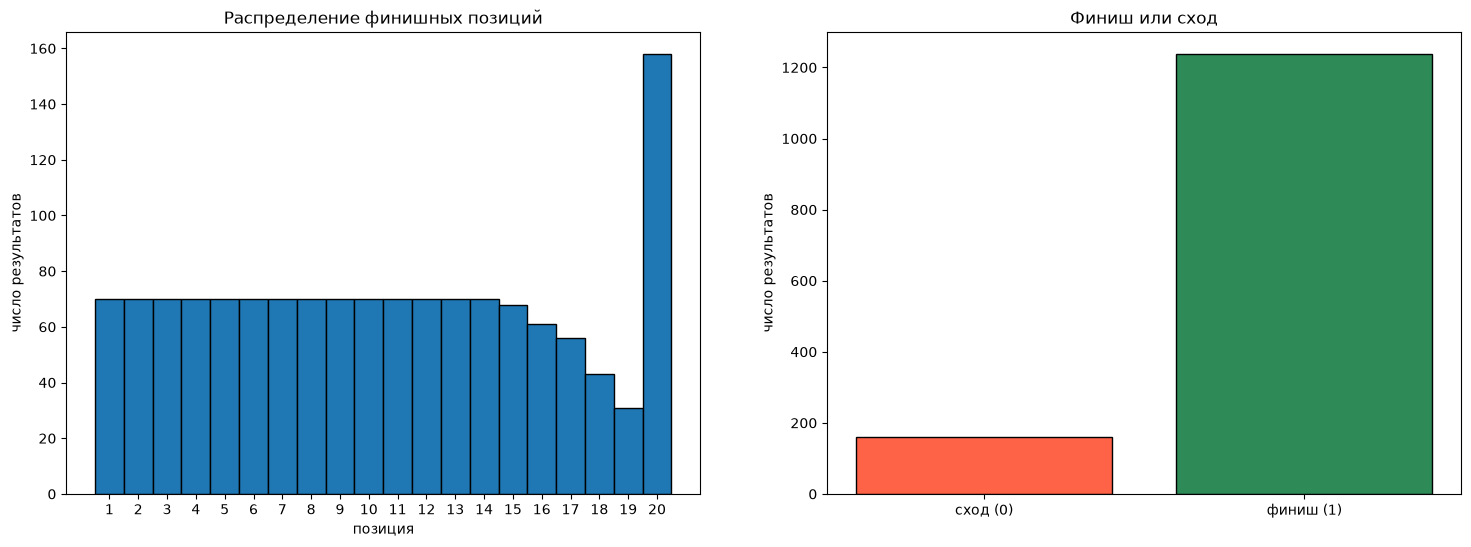

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

ax[0].hist(race["position_filled"], bins=range(1, 22), edgecolor="black", align="left")
ax[0].set_title("Распределение финишных позиций")
ax[0].set_xlabel("позиция")
ax[0].set_ylabel("число результатов")
ax[0].set_xticks(range(1, 21))

counts = race["finished"].value_counts().sort_index()
ax[1].bar(["сход (0)", "финиш (1)"], counts.values, color=["tomato", "seagreen"], edgecolor="black")
ax[1].set_title("Финиш или сход")
ax[1].set_ylabel("число результатов")

plt.show()

Смотрим пропуски

In [75]:
# пропуски по всем колонкам 
missing = race.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Колонки с пропусками:")
print(missing)

#проверим пропуски в инженерных признаках 
feature_cols = [
    "quali_position", "driver_form_5", "driver_form_all", "team_form_5",
    "driver_track_history", "driver_finish_rate", "driver_experience",
    "driver_speed_5", "is_rookie", "field_size",
]
print("\nПропуски в признаках для модели:", race[feature_cols].isna().sum().sum())

Колонки с пропусками:
best_time         473
gap_to_leader     177
position          154
avg_i2_speed       52
best_lap           37
avg_lap            37
avg_i1_speed       28
avg_st_speed       23
max_st_speed       23
number_of_laps      7
laps_count          3
dtype: int64

Пропуски в признаках для модели: 0


Распределение по сезонам

In [76]:
print("Строк по сезонам:")
print(race["year"].value_counts().sort_index())
print("\nГонок по сезонам:")
print(race.groupby("year")["session_key"].nunique())

Строк по сезонам:
year
2023    439
2024    479
2025    479
Name: count, dtype: int64

Гонок по сезонам:
year
2023    22
2024    24
2025    24
Name: session_key, dtype: int64


учим на 2023-2024, тестируем на 2025 (без перемешивания, чтобы не было утечки из будущего)

Посмотрим корреляции числовых признаков с позицией

driver_finish_rate     -0.238
driver_experience      -0.110
air_temp_mean          -0.009
track_temp_mean        -0.007
wind_speed_mean         0.002
humidity_mean           0.003
rainfall_max            0.011
field_size              0.018
is_rookie               0.032
driver_speed_5          0.034
driver_track_history    0.310
team_form_5             0.525
driver_form_all         0.564
driver_form_5           0.567
quali_position          0.640
Name: position_filled, dtype: float64


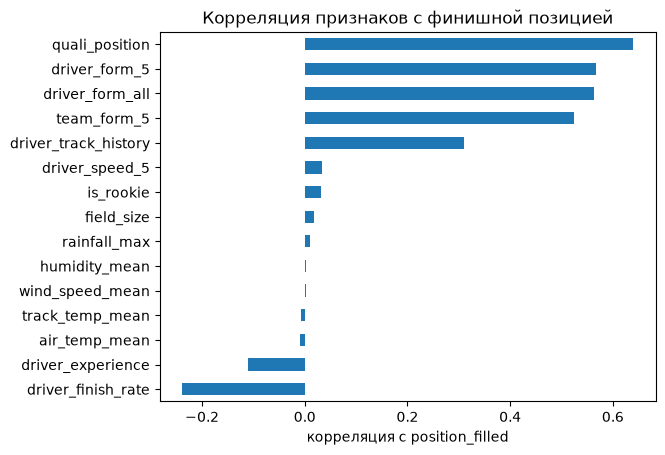

In [77]:
feats = ["quali_position", "driver_form_5", "driver_form_all", "team_form_5",
         "driver_track_history", "driver_finish_rate", "driver_experience",
         "driver_speed_5", "is_rookie", "field_size",
         "air_temp_mean", "track_temp_mean", "humidity_mean", "wind_speed_mean", "rainfall_max"]

corr = race[feats + ["position_filled"]].corr()["position_filled"].drop("position_filled")
corr = corr.sort_values()
print(corr.round(3))

corr.plot(kind="barh")
plt.title("Корреляция признаков с финишной позицией")
plt.xlabel("корреляция с position_filled")
plt.show()

Посмотрим на главнй признак - стартовую позицию из квалы. Сначала точечный график старт против финиша, потом средний финиш для каждого стартового места.

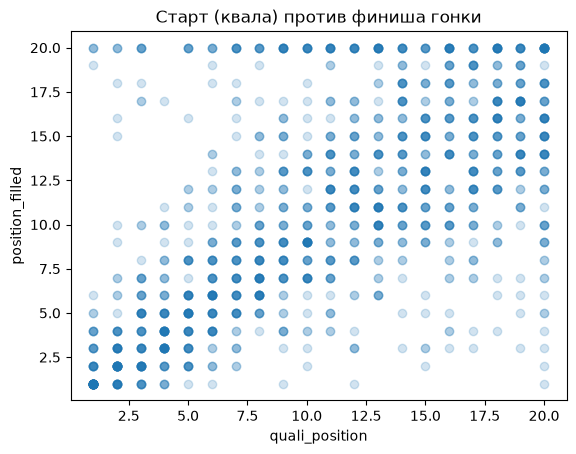

In [78]:
plt.scatter(race["quali_position"], race["position_filled"], alpha=0.2)
plt.title("Старт (квала) против финиша гонки")
plt.xlabel("quali_position")
plt.ylabel("position_filled")
plt.show()

quali_position
1.0      2.8
2.0      4.1
3.0      5.6
4.0      4.6
5.0      6.5
6.0      7.6
7.0      9.4
8.0      9.5
9.0     11.1
10.0    11.0
11.0    12.4
12.0    12.3
13.0    13.0
14.0    14.3
15.0    13.3
16.0    14.4
17.0    14.1
18.0    15.4
19.0    15.3
20.0    14.5
Name: position_filled, dtype: float64


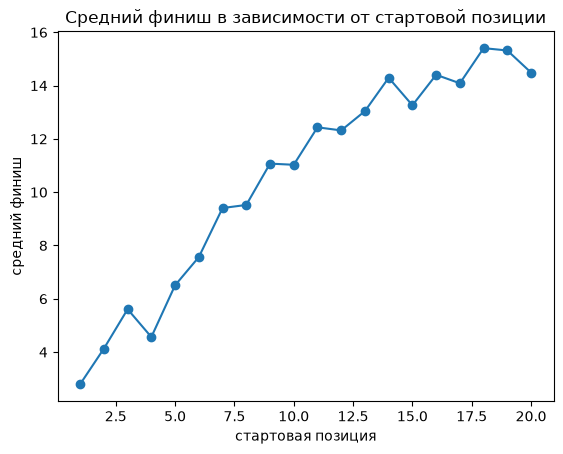

In [79]:
grid = race.groupby("quali_position")["position_filled"].mean()
print(grid.round(1))

grid.plot(marker="o")
plt.title("Средний финиш в зависимости от стартовой позиции")
plt.xlabel("стартовая позиция")
plt.ylabel("средний финиш")
plt.show()

Теперь посмотрим среднюю финишную позицию по каждой команде чтобы посмотреть на топов

team_name
McLaren             6.1
Red Bull Racing     6.3
Ferrari             7.0
Mercedes            7.2
Aston Martin       11.3
Racing Bulls       13.1
Haas F1 Team       13.2
Alpine             13.4
Williams           13.8
Kick Sauber        14.6
Name: position_filled, dtype: float64


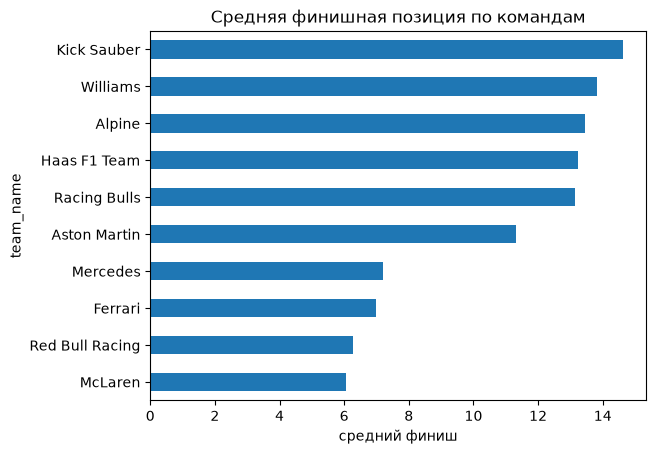

In [80]:
team_strength = race.groupby("team_name")["position_filled"].mean().sort_values()
print(team_strength.round(1))

team_strength.plot(kind="barh")
plt.title("Средняя финишная позиция по командам")
plt.xlabel("средний финиш")
plt.show()

Проверяем погоду: делим гонки на сухие и с дождём и сравниваем долю сходов. Заодно убедимся числами, что погодные признаки тут слабые

In [81]:
dry = race[race["rainfall_max"] == 0]
wet = race[race["rainfall_max"] > 0]

print("Сухо: строк", len(dry), "доля сходов", round((dry["dnf"] == True).mean(), 3))
print("Дождь: строк", len(wet), "доля сходов", round((wet["dnf"] == True).mean(), 3))

Сухо: строк 1077 доля сходов 0.113
Дождь: строк 320 доля сходов 0.116


В общем могу сказать, что результат гонки в основном определяется стартовой позицией, формой пилота и силой команды, а погода и телеметрийная скорость - почти шум.

Построим корреляционную матрицу всех признаков между собой и нарисуем тепловую карту

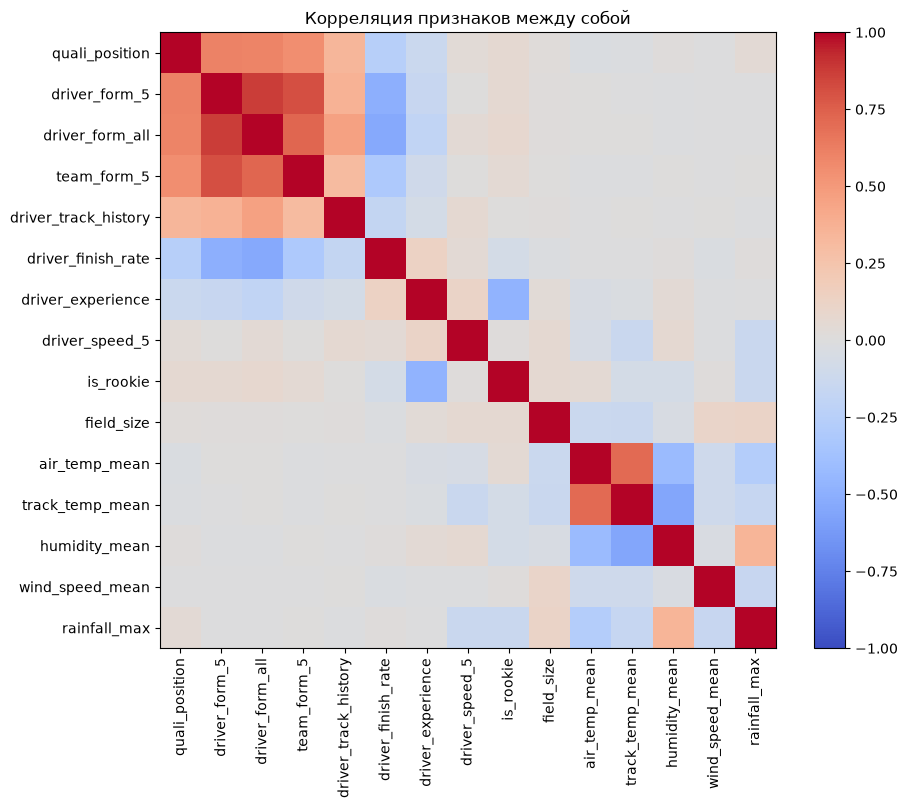

In [82]:
feats = ["quali_position", "driver_form_5", "driver_form_all", "team_form_5",
         "driver_track_history", "driver_finish_rate", "driver_experience",
         "driver_speed_5", "is_rookie", "field_size",
         "air_temp_mean", "track_temp_mean", "humidity_mean", "wind_speed_mean", "rainfall_max"]

corr_matrix = race[feats].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(feats)), feats, rotation=90)
plt.yticks(range(len(feats)), feats)
plt.title("Корреляция признаков между собой")
plt.show()

Смотрим на пары у которых корреляцию больше 0,6 - это кандидаты на лишние дубли, но пока их убирать не будем

In [83]:
c = race[feats].corr().abs()
for i in range(len(feats)):
    for j in range(i + 1, len(feats)):
        if c.iloc[i, j] > 0.6:
            print(feats[i], "/", feats[j], "=", round(c.iloc[i, j], 3))

quali_position / driver_form_5 = 0.606
driver_form_5 / driver_form_all = 0.875
driver_form_5 / team_form_5 = 0.806
driver_form_all / team_form_5 = 0.719
air_temp_mean / track_temp_mean = 0.707
